In [203]:
##Cargar los Datos
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [204]:
path = "/content/drive/MyDrive/"

In [205]:
# 0. Importamos las librerías:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [206]:
df = pd.read_csv(path + 'perfum.csv', encoding="latin-1", sep=';')
df.head()

,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
0,https://www.fragrantica.com/perfume/xerjoff/ac...,accento-overdose-pride-edition,xerjoff,Italy,unisex,"1,42",201,2022.0,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",unknown,NaN,rose,woody,fruity,aromatic,floral
1,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2024,jean-paul-gaultier,France,women,"1,86",70,2024.0,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",unknown,NaN,citrus,white floral,sweet,fresh,musky
2,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2023,jean-paul-gaultier,France,unisex,"1,91",285,2023.0,"blood orange, yuzu","neroli, orange blossom","musk, white woods",natalie gracia-cetto,quentin bisch,citrus,white floral,sweet,fresh spicy,musky
3,https://www.fragrantica.com/perfume/bruno-bana...,pride-edition-man,bruno-banani,Germany,men,"1,92",59,2019.0,"guarana, grapefruit, red apple","walnut, lavender, guava","vetiver, benzoin, amber",unknown,NaN,fruity,nutty,woody,tropical,NaN
4,https://www.fragrantica.com/perfume/jean-paul-...,le-male-pride-collector,jean-paul-gaultier,France,men,"1,93",632,2020.0,"mint, lavender, cardamom, artemisia, bergamot","caraway, cinnamon, orange blossom","vanilla, sandalwood, amber, cedar, tonka bean",francis kurkdjian,NaN,aromatic,warm spicy,fresh spicy,cinnamon,vanilla


In [207]:

def asignar_familia(row):
    accords = [
        row['mainaccord1'],
        row['mainaccord2'],
        row['mainaccord3']
    ]

    accords = [str(a).lower() for a in accords if pd.notnull(a)]

    # 1. Sweet / Gourmand
    if any(a in accords for a in ['vanilla', 'sweet', 'gourmand', 'caramel', 'chocolate']):
        return 'Sweet / Gourmand'

    # 2. Floral
    if any(a in accords for a in ['floral', 'white floral', 'rose', 'tuberose', 'powdery']):
        return 'Floral'

    # 3. Woody / Amber
    if any(a in accords for a in ['woody', 'amber', 'warm spicy', 'leather', 'tobacco', 'smoky']):
        return 'Woody / Amber'

    # 4. Green / Earthy
    if any(a in accords for a in ['green', 'earthy', 'herbal']):
        return 'Green / Earthy'

    # 5. Fresh / Citrus
    if any(a in accords for a in ['citrus', 'aromatic', 'aquatic', 'fresh', 'ozonic']):
        return 'Fresh / Citrus'

    return 'Other'

In [208]:
df_filtrado = df[df['Rating Count'] >= 80].copy()
df_filtrado['familia_olfativa'] = df_filtrado.apply(asignar_familia, axis=1)
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15368 entries, 0 to 24050
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   url               15368 non-null  object 
 1   Perfume           15368 non-null  object 
 2   Brand             15368 non-null  object 
 3   Country           15368 non-null  object 
 4   Gender            15368 non-null  object 
 5   Rating Value      15368 non-null  object 
 6   Rating Count      15368 non-null  int64  
 7   Year              14497 non-null  float64
 8   Top               15368 non-null  object 
 9   Middle            15368 non-null  object 
 10  Base              15368 non-null  object 
 11  Perfumer1         15368 non-null  object 
 12  Perfumer2         1094 non-null   object 
 13  mainaccord1       15368 non-null  object 
 14  mainaccord2       15360 non-null  object 
 15  mainaccord3       15306 non-null  object 
 16  mainaccord4       15141 non-null  object 
 17

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24063 entries, 0 to 24062
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           24063 non-null  object 
 1   Perfume       24063 non-null  object 
 2   Brand         24063 non-null  object 
 3   Country       24063 non-null  object 
 4   Gender        24063 non-null  object 
 5   Rating Value  24063 non-null  object 
 6   Rating Count  24063 non-null  int64  
 7   Year          22026 non-null  float64
 8   Top           24063 non-null  object 
 9   Middle        24063 non-null  object 
 10  Base          24063 non-null  object 
 11  Perfumer1     24063 non-null  object 
 12  Perfumer2     1336 non-null   object 
 13  mainaccord1   24063 non-null  object 
 14  mainaccord2   24050 non-null  object 
 15  mainaccord3   23949 non-null  object 
 16  mainaccord4   23675 non-null  object 
 17  mainaccord5   23082 non-null  object 
dtypes: float64(1), int64(1), o

In [210]:
df2 = pd.read_csv(path + 'fra_perfumes.csv', encoding="latin-1")
df2.head()

,Name,Gender,Rating Value,Rating Count,Main Accords,Perfumers,Description,url
0,9am Afnanfor women,for women,3.73,174,"['citrus', 'musky', 'woody', 'aromatic', 'warm...",[],9ambyAfnanis a fragrance for women. Top notes ...,https://www.fragrantica.com/perfume/Afnan/9am-...
1,9am Dive Afnanfor women and men,for women and men,4.29,842,"['fruity', 'woody', 'green', 'warm spicy', 'ar...",[],9am DivebyAfnanis a Aromatic Aquatic fragrance...,https://www.fragrantica.com/perfume/Afnan/9am-...
2,9am pour Femme Afnanfor women,for women,4.00,68,"['fruity', 'musky', 'amber', 'citrus', 'powder...",[],9am pour FemmebyAfnanis a Amber fragrance for ...,https://www.fragrantica.com/perfume/Afnan/9am-...
3,9pm Afnanfor men,for men,4.50,"6,865","['vanilla', 'amber', 'warm spicy', 'cinnamon',...",[],9pmbyAfnanis a Amber Vanilla fragrance for men...,https://www.fragrantica.com/perfume/Afnan/9pm-...
4,9pm pour Femme Afnanfor women,for women,3.49,63,"['woody', 'aromatic', 'rose', 'fruity', 'powde...",[],9pm pour FemmebyAfnanis a Amber Floral fragran...,https://www.fragrantica.com/perfume/Afnan/9pm-...


In [211]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70103 entries, 0 to 70102
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          70100 non-null  object 
 1   Gender        70100 non-null  object 
 2   Rating Value  63922 non-null  float64
 3   Rating Count  63922 non-null  object 
 4   Main Accords  70103 non-null  object 
 5   Perfumers     70103 non-null  object 
 6   Description   70100 non-null  object 
 7   url           70103 non-null  object 
dtypes: float64(1), object(7)
memory usage: 4.3+ MB


In [212]:
df_pe1 = pd.read_csv(path + 'perfumes_extraidos_1.csv')
df_pe1

,url,nombre,descripcion,marca,anio,genero,top_notes,middle_notes,base_notes,accords,rating,votes,error
0,https://www.fragrantica.com/perfume/Lattafa-Pe...,Khamrah Lattafa Perfumes for women and men,Khamrah by Lattafa Perfumes is a Oriental Spic...,Lattafa Perfumes,2022,women and men,"Cinnamon, Nutmeg and Bergamot","Dates, Praline, Tuberose and Mahonial","Vanilla, Tonka Bean, Amberwood, Myrrh, Benzoin...",sweet | warm spicy | vanilla | amber | cinnamo...,2.97,26819,NaN
1,https://www.fragrantica.com/perfume/Lattafa-Pe...,Khamrah Qahwa Lattafa Perfumes for women and men,Khamrah Qahwa by Lattafa Perfumes is a Orienta...,Lattafa Perfumes,2023,women and men,"Cinnamon, Cardamom and Ginger","Praline, Candied Fruits and White Flowers","Vanilla, Coffee, Tonka Bean, Benzoin and Musk",warm spicy | sweet | vanilla | cinnamon | coff...,7.79,13318,NaN
2,https://www.fragrantica.com/perfume/Lattafa-Pe...,Eclaire Lattafa Perfumes for women,Eclaire by Lattafa Perfumes is a Floral Fruity...,Lattafa Perfumes,2024,women,"Caramel, Milk and Sugar",Honey and White Flowers,"Vanilla, Praline and Musk",sweet | vanilla | caramel | lactonic | honey |...,2.97,8100,NaN
3,https://www.fragrantica.com/perfume/Lattafa-Pe...,Asad Lattafa Perfumes for men,Asad by Lattafa Perfumes is a Oriental fragran...,Lattafa Perfumes,2021,men,"Black Pepper, Tobacco and Pineapple","Patchouli, Coffee and Iris","Vanilla, Amber, Dry Wood, Benzoin and Labdanum",amber | fresh spicy | woody | warm spicy | van...,8.44,12626,NaN
4,https://www.fragrantica.com/perfume/Lattafa-Pe...,Yara Lattafa Perfumes for women,Yara by Lattafa Perfumes is a Oriental Vanilla...,Lattafa Perfumes,2020,women,"Orchid, Heliotrope and Tangerine",Gourmand Accord and Tropical Fruits,"Vanilla, Musk and Sandalwood",sweet | vanilla | powdery | tropical | fruity ...,5.19,10749,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,https://www.fragrantica.com/perfume/Giorgio-Ar...,Thé Yulong Giorgio Armani for women and men,Thé Yulong by Giorgio Armani is a Aromatic Gre...,Giorgio Armani,2020,women and men,"Mandarin Orange, Petitgrain and Cardamom","Green Tea, Black Tea, Orange Blossom and Jasmine","Vetiver, Ambrette (Musk Mallow) and Iris",citrus | green | white floral | aromatic | woo...,4.25,1715,NaN
121,https://www.fragrantica.com/perfume/Giorgio-Ar...,Emporio Armani Stronger With You Powerfully Gi...,Emporio Armani Stronger With You Powerfully by...,Giorgio Armani,2026,men,Cherry and Mandarin Orange,Spices and Lavender,"Chestnut, Vanilla and Amberwood",warm spicy | cherry | amber | vanilla | nutty ...,4.47,1224,NaN
122,https://www.fragrantica.com/perfume/Giorgio-Ar...,Acqua di Giò Eau de Parfum Giorgio Armani for men,Acqua di Giò Eau de Parfum by Giorgio Armani i...,Giorgio Armani,2022,men,Sea Notes and Green Mandarin,"Clary Sage, Lavender and Geranium","Mineral notes, Vetiver and Patchouli",aromatic | marine | mineral | citrus | fresh s...,4.94,3638,NaN
123,https://www.fragrantica.com/perfume/Giorgio-Ar...,My Way Ylang Giorgio Armani for women,My Way Ylang by Giorgio Armani is a Floral Fru...,Giorgio Armani,2024,women,"Mango, Coconut, Orange Blossom and Bergamot",Ylang Ylang and Tuberose,"Vanilla, White Musk and Cedarwood",sweet | tropical | white floral | yellow flora...,3.09,787,NaN


In [213]:
df_pe2 = pd.read_csv(path + 'perfumes_extraidos_2.csv')
df_pe2

,url,nombre,descripcion,marca,anio,genero,top_notes,middle_notes,base_notes,accords,rating,votes,error
0,https://www.fragrantica.com/perfume/Tom-Ford/T...,Tobacco Vanille Tom Ford for women and men,Tobacco Vanille by Tom Ford is a Oriental Spic...,Tom Ford,2007.0,women and men,Tobacco Leaf and Spicy Notes,"Vanilla, Cacao, Tonka Bean and Tobacco Blossom",Dried Fruits and Woody Notes,vanilla | sweet | tobacco | warm spicy | fruit...,7.99,29747,NaN
1,https://www.fragrantica.com/perfume/Tom-Ford/O...,Ombré Leather (2018) Tom Ford for women and men,Ombré Leather (2018) by Tom Ford is a Leather ...,Tom Ford,2018.0,women and men,NaN,Leather and Jasmine Sambac,"Amber, Moss and Patchouli",leather | animalic | warm spicy | white floral...,0.30,17040,NaN
2,https://www.fragrantica.com/perfume/Tom-Ford/L...,Lost Cherry Tom Ford for women and men,Lost Cherry by Tom Ford is a Oriental Floral f...,Tom Ford,2018.0,women and men,"Bitter Almond, Black Cherry and Cherry Liqueur","Sour Cherry, Plum, Turkish Rose and Jasmine Sa...","Vanilla, Tonka Bean, Cinnamon, Peru Balsam, Sa...",cherry | sweet | almond | nutty | fruity | van...,8.97,16887,NaN
3,https://www.fragrantica.com/perfume/Tom-Ford/B...,Black Orchid Tom Ford for women,Black Orchid by Tom Ford is a Oriental Floral ...,Tom Ford,2006.0,women,"Truffle, Gardenia, Black Currant, Ylang-Ylang,...","Orchid, Spices, Gardenia, Fruity Notes, Ylang-...","Mexican chocolate, Patchouli, Vanille, Incense...",warm spicy | earthy | woody | sweet | amber | ...,3.97,31333,NaN
4,https://www.fragrantica.com/perfume/Tom-Ford/O...,Oud Wood Tom Ford for women and men,Oud Wood by Tom Ford is a Oriental Woody fragr...,Tom Ford,2007.0,women and men,NaN,NaN,NaN,woody | warm spicy | oud | aromatic | vanilla ...,6.97,16624,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,https://www.fragrantica.com/perfume/Versace/Cr...,Crystal Noir Eau de Toilette Versace for women,Crystal Noir Eau de Toilette by Versace is a F...,Versace,2004.0,women,"Pepper, Cardamom and Ginger","Gardenia, Orange Blossom and Peony","Sandalwood, Musk and Amber",warm spicy | woody | fresh spicy | white flora...,3.89,3746,NaN
246,https://www.fragrantica.com/perfume/Versace/Ve...,Versace Pour Homme Oud Noir Versace for men,Versace Pour Homme Oud Noir by Versace is a Or...,Versace,2013.0,men,"Black Pepper, Bitter Orange and Neroli","Saffron, Cardamom and Olibanum","Agarwood (Oud), Patchouli and Leatherwood",warm spicy | oud | fresh spicy | citrus | wood...,2.99,3679,NaN
247,https://www.fragrantica.com/perfume/Versace/Cr...,Crystal Emerald Versace for women,Crystal Emerald by Versace is a Floral Fruity ...,Versace,2025.0,women,"Bergamot, Peach and Pink Pepper","Rosebud, Sorbet, Jasmine and Raspberry","White Musk, Tonka Bean and Incense",musky | sweet | fruity | citrus | powdery | wh...,3.71,652,NaN
248,https://www.fragrantica.com/perfume/Versace/Er...,Eros Pour Femme Versace for women,Eros Pour Femme by Versace is a Floral Woody M...,Versace,2014.0,women,"Sicilian Lemon, Pomegranate and Calabrian berg...","Lemon Blossom, Jasmine Sambac, Jasmine and Peony","Musk, Ambroxan, Woodsy Notes and Sandalwood",citrus | white floral | woody | musky | floral...,1.50,5021,NaN


In [214]:
df_pe3 = pd.read_csv(path + 'perfumes_extraidos_3.csv', encoding='latin-1')
df_pe3

,url,nombre,descripcion,marca,anio,genero,top_notes,middle_notes,base_notes,accords,rating,votes,error
0,https://www.fragrantica.com/perfume/Dolce-Gabb...,Devotion Dolce&Gabbana for women,Devotion by Dolce&Gabbana is a Oriental Vanill...,Dolce&Gabbana,2023.0,women,NaN,"Panacotta, Orange Blossom and Rum",NaN,vanilla | sweet | white floral | lactonic | po...,3.97,11274.0,NaN
1,https://www.fragrantica.com/perfume/Dolce-Gabb...,Light Blue Dolce&Gabbana for women,Light Blue by Dolce&Gabbana is a Floral Fruity...,Dolce&Gabbana,2001.0,women,"Sicilian Lemon, Apple, Cedar and Bellflower","Bamboo, Jasmine and White Rose","Cedar, Musk and Amber",citrus | woody | fresh | fruity | aromatic | m...,2.97,35124.0,NaN
2,https://www.fragrantica.com/perfume/Dolce-Gabb...,The One for Men Eau de Parfum Dolce&Gabbana fo...,The One for Men Eau de Parfum by Dolce&Gabbana...,Dolce&Gabbana,2015.0,men,"Grapefruit, Coriander and Basil","Cardamom, Ginger and Orange Blossom","Amber, Tobacco and Cedar",amber | tobacco | fresh spicy | citrus | aroma...,4.54,15390.0,NaN
3,https://www.fragrantica.com/perfume/Dolce-Gabb...,Light Blue Eau Intense Pour Homme Dolce&Gabban...,Light Blue Eau Intense Pour Homme by Dolce&Gab...,Dolce&Gabbana,2017.0,men,Grapefruit and Mandarin Orange,Sea water and Juniper,Musk and Amberwood,citrus | aromatic | marine | fresh spicy | woo...,2.99,10684.0,NaN
4,https://www.fragrantica.com/perfume/Dolce-Gabb...,Devotion Intense Dolce&Gabbana for women,Devotion Intense by Dolce&Gabbana is a Orienta...,Dolce&Gabbana,2024.0,women,hazelnut,orange blossom,vanilla,vanilla | nutty | white floral | sweet | woody...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,https://www.fragrantica.com/perfume/Bath-Body-...,Pistachio Glaze Bath & Body Works for women,Pistachio Glaze by Bath & Body Works is a Orie...,Bath & Body Works,2025.0,women,NaN,NaN,NaN,vanilla | sweet | woody | nutty | green | powdery,4.25,349.0,NaN
371,https://www.fragrantica.com/perfume/Bath-Body-...,Pure Wonder Bath & Body Works for women,Pure Wonder by Bath & Body Works is a Oriental...,Bath & Body Works,2021.0,women,NaN,NaN,NaN,white floral | fresh | amber | rose | floral |...,4.22,920.0,NaN
372,https://www.fragrantica.com/perfume/Bath-Body-...,Gingham Bath & Body Works for women,Gingham by Bath & Body Works is a Citrus fragr...,Bath & Body Works,2019.0,women,NaN,NaN,NaN,floral | citrus | violet | sweet | powdery | f...,3.98,844.0,NaN
373,https://www.fragrantica.com/perfume/Bath-Body-...,Sweetest Song Bath & Body Works for women,Sweetest Song by Bath & Body Works is a Floral...,Bath & Body Works,2025.0,women,NaN,NaN,NaN,sweet | fruity | musky | powdery | vanilla,4.22,325.0,NaN


In [215]:
df_pe4 = pd.read_csv(path + 'perfumes_extraidos_4.csv')
df_pe5 = pd.read_csv(path + 'perfumes_extraidos_5.csv')

In [216]:
df_pe1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           125 non-null    object 
 1   nombre        125 non-null    object 
 2   descripcion   125 non-null    object 
 3   marca         125 non-null    object 
 4   anio          125 non-null    int64  
 5   genero        125 non-null    object 
 6   top_notes     103 non-null    object 
 7   middle_notes  103 non-null    object 
 8   base_notes    109 non-null    object 
 9   accords       125 non-null    object 
 10  rating        125 non-null    float64
 11  votes         125 non-null    int64  
 12  error         0 non-null      float64
dtypes: float64(2), int64(2), object(9)
memory usage: 12.8+ KB


In [217]:
df_pe2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           250 non-null    object 
 1   nombre        250 non-null    object 
 2   descripcion   250 non-null    object 
 3   marca         250 non-null    object 
 4   anio          245 non-null    float64
 5   genero        250 non-null    object 
 6   top_notes     212 non-null    object 
 7   middle_notes  215 non-null    object 
 8   base_notes    213 non-null    object 
 9   accords       250 non-null    object 
 10  rating        250 non-null    float64
 11  votes         250 non-null    int64  
 12  error         0 non-null      float64
dtypes: float64(3), int64(1), object(9)
memory usage: 25.5+ KB


In [218]:
df_pe3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           375 non-null    object 
 1   nombre        375 non-null    object 
 2   descripcion   375 non-null    object 
 3   marca         375 non-null    object 
 4   anio          366 non-null    float64
 5   genero        375 non-null    object 
 6   top_notes     280 non-null    object 
 7   middle_notes  290 non-null    object 
 8   base_notes    291 non-null    object 
 9   accords       375 non-null    object 
 10  rating        370 non-null    float64
 11  votes         370 non-null    float64
 12  error         0 non-null      float64
dtypes: float64(4), object(9)
memory usage: 38.2+ KB


In [219]:
df_pe4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           150 non-null    object 
 1   nombre        150 non-null    object 
 2   descripcion   148 non-null    object 
 3   marca         148 non-null    object 
 4   anio          147 non-null    float64
 5   genero        148 non-null    object 
 6   top_notes     98 non-null     object 
 7   middle_notes  99 non-null     object 
 8   base_notes    109 non-null    object 
 9   accords       149 non-null    object 
 10  rating        148 non-null    float64
 11  votes         148 non-null    float64
 12  error         0 non-null      float64
dtypes: float64(4), object(9)
memory usage: 15.4+ KB


In [220]:
df_pe5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           150 non-null    object 
 1   nombre        150 non-null    object 
 2   descripcion   147 non-null    object 
 3   marca         147 non-null    object 
 4   anio          147 non-null    float64
 5   genero        147 non-null    object 
 6   top_notes     105 non-null    object 
 7   middle_notes  107 non-null    object 
 8   base_notes    110 non-null    object 
 9   accords       149 non-null    object 
 10  rating        147 non-null    float64
 11  votes         147 non-null    float64
 12  error         0 non-null      float64
dtypes: float64(4), object(9)
memory usage: 15.4+ KB


In [221]:
# 1. Eliminamos la columna error
df_pe1 = df_pe1.drop(columns=['error'], errors='ignore')
df_pe2 = df_pe2.drop(columns=['error'], errors='ignore')
df_pe3 = df_pe3.drop(columns=['error'], errors='ignore')
df_pe4 = df_pe4.drop(columns=['error'], errors='ignore')
df_pe5 = df_pe5.drop(columns=['error'], errors='ignore')

In [222]:
# 2 Concatenamos
df_perfumes = pd.concat([df_pe1, df_pe2, df_pe3,df_pe4, df_pe5], ignore_index=True)
df_perfumes

,url,nombre,descripcion,marca,anio,genero,top_notes,middle_notes,base_notes,accords,rating,votes
0,https://www.fragrantica.com/perfume/Lattafa-Pe...,Khamrah Lattafa Perfumes for women and men,Khamrah by Lattafa Perfumes is a Oriental Spic...,Lattafa Perfumes,2022.0,women and men,"Cinnamon, Nutmeg and Bergamot","Dates, Praline, Tuberose and Mahonial","Vanilla, Tonka Bean, Amberwood, Myrrh, Benzoin...",sweet | warm spicy | vanilla | amber | cinnamo...,2.97,26819.0
1,https://www.fragrantica.com/perfume/Lattafa-Pe...,Khamrah Qahwa Lattafa Perfumes for women and men,Khamrah Qahwa by Lattafa Perfumes is a Orienta...,Lattafa Perfumes,2023.0,women and men,"Cinnamon, Cardamom and Ginger","Praline, Candied Fruits and White Flowers","Vanilla, Coffee, Tonka Bean, Benzoin and Musk",warm spicy | sweet | vanilla | cinnamon | coff...,7.79,13318.0
2,https://www.fragrantica.com/perfume/Lattafa-Pe...,Eclaire Lattafa Perfumes for women,Eclaire by Lattafa Perfumes is a Floral Fruity...,Lattafa Perfumes,2024.0,women,"Caramel, Milk and Sugar",Honey and White Flowers,"Vanilla, Praline and Musk",sweet | vanilla | caramel | lactonic | honey |...,2.97,8100.0
3,https://www.fragrantica.com/perfume/Lattafa-Pe...,Asad Lattafa Perfumes for men,Asad by Lattafa Perfumes is a Oriental fragran...,Lattafa Perfumes,2021.0,men,"Black Pepper, Tobacco and Pineapple","Patchouli, Coffee and Iris","Vanilla, Amber, Dry Wood, Benzoin and Labdanum",amber | fresh spicy | woody | warm spicy | van...,8.44,12626.0
4,https://www.fragrantica.com/perfume/Lattafa-Pe...,Yara Lattafa Perfumes for women,Yara by Lattafa Perfumes is a Oriental Vanilla...,Lattafa Perfumes,2020.0,women,"Orchid, Heliotrope and Tangerine",Gourmand Accord and Tropical Fruits,"Vanilla, Musk and Sandalwood",sweet | vanilla | powdery | tropical | fruity ...,5.19,10749.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1045,https://www.fragrantica.com/perfume/O-Boticari...,Quasar Ice O Boticário for men,Quasar Ice by O Boticário is a Aromatic fragra...,O Boticário,2021.0,men,"Watery Notes, Ice, Lime, Sage and Cardamom","Artemisia, Lavender, Bourbon Geranium, Cedar a...","Mountain Air, Oakmoss, Musk, Cedar, Cashmeran,...",fresh | aquatic | aromatic | herbal | fresh sp...,3.99,716.0
1046,https://www.fragrantica.com/perfume/O-Boticari...,L’eau de Lily Blanche O Boticário for women,L’eau de Lily Blanche by O Boticário is a Flor...,O Boticário,2025.0,women,"Bergamot, Mandarin Orange and Pink Pepper","Tuberose, Jasmine and Freesia","White Musk, Vanilla, Cedar, Amberwood and Moss",white floral | citrus | musky | tuberose | woo...,4.27,293.0
1047,https://www.fragrantica.com/perfume/O-Boticari...,Coffee Duo Woman O Boticário for women,Coffee Duo Woman by O Boticário is a Floral Fr...,O Boticário,2018.0,women,"Lavender, Fruity Notes and Bergamot","Milk, Coffee, Jasmine Sambac, Orchid, Ylang-Yl...","Benzoin, Sandalwood, Musk and Patchouli",warm spicy | lactonic | lavender | woody | cof...,4.18,1097.0
1048,https://www.fragrantica.com/perfume/O-Boticari...,Egeo Spicy Vibe O Boticário for women and men,Egeo Spicy Vibe by O Boticário is a Aromatic F...,O Boticário,2020.0,women and men,"Black Pepper, Grapefruit, Lemon and Bergamot","Cardamom, Coriander, Sage and Geranium","Vanilla, Cedar, Sandalowood, Cashmeran, Patcho...",fresh spicy | warm spicy | aromatic | woody | ...,4.03,886.0


In [223]:
df_perfumes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           1050 non-null   object 
 1   nombre        1050 non-null   object 
 2   descripcion   1045 non-null   object 
 3   marca         1045 non-null   object 
 4   anio          1030 non-null   float64
 5   genero        1045 non-null   object 
 6   top_notes     798 non-null    object 
 7   middle_notes  814 non-null    object 
 8   base_notes    832 non-null    object 
 9   accords       1048 non-null   object 
 10  rating        1040 non-null   float64
 11  votes         1040 non-null   float64
dtypes: float64(3), object(9)
memory usage: 98.6+ KB


In [224]:
df_perfumes = df_perfumes[
    df_perfumes['descripcion'].notna() &
    (df_perfumes['descripcion'].str.strip() != '')
].reset_index(drop=True)

In [225]:
print(df_perfumes.shape)
df_perfumes.isnull().sum()

(1045, 12)


,0
url,0
nombre,0
descripcion,0
marca,0
anio,15
genero,0
top_notes,247
middle_notes,231
base_notes,213
accords,0


In [226]:
df_perfumes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1045 entries, 0 to 1044
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           1045 non-null   object 
 1   nombre        1045 non-null   object 
 2   descripcion   1045 non-null   object 
 3   marca         1045 non-null   object 
 4   anio          1030 non-null   float64
 5   genero        1045 non-null   object 
 6   top_notes     798 non-null    object 
 7   middle_notes  814 non-null    object 
 8   base_notes    832 non-null    object 
 9   accords       1045 non-null   object 
 10  rating        1040 non-null   float64
 11  votes         1040 non-null   float64
dtypes: float64(3), object(9)
memory usage: 98.1+ KB


In [227]:
cols_texto = [
    'nombre', 'descripcion', 'marca', 'genero',
    'top_notes', 'middle_notes', 'base_notes', 'accords'
]

for col in cols_texto:
    df_perfumes[col] = df_perfumes[col].fillna('')

In [228]:
# 3 Estandarizamos tipos
df_perfumes['anio'] = df_perfumes['anio'].fillna(0)
df_perfumes['rating'] = df_perfumes['rating'].fillna(df_perfumes['rating'].median())
df_perfumes['votes'] = df_perfumes['votes'].fillna(0)

In [229]:
# 4 Validamos duplicados
print("Filas antes de eliminar duplicados:", df_perfumes.shape[0])
df_perfumes = df_perfumes.drop_duplicates(subset=['url']).reset_index(drop=True)
print("Filas después de eliminar duplicados:", df_perfumes.shape[0])

Filas antes de eliminar duplicados: 1045
Filas después de eliminar duplicados: 1045


In [230]:
# 5 Revisamos nulos
print("\nValores nulos por columna:")
print(df_perfumes.isnull().sum())


Valores nulos por columna:
url             0
nombre          0
descripcion     0
marca           0
anio            0
genero          0
top_notes       0
middle_notes    0
base_notes      0
accords         0
rating          0
votes           0
dtype: int64


In [231]:
# 6 Vista general
print("\nInfo final:")
print(df_perfumes.info())
df_perfumes.head()


Info final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1045 entries, 0 to 1044
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           1045 non-null   object 
 1   nombre        1045 non-null   object 
 2   descripcion   1045 non-null   object 
 3   marca         1045 non-null   object 
 4   anio          1045 non-null   float64
 5   genero        1045 non-null   object 
 6   top_notes     1045 non-null   object 
 7   middle_notes  1045 non-null   object 
 8   base_notes    1045 non-null   object 
 9   accords       1045 non-null   object 
 10  rating        1045 non-null   float64
 11  votes         1045 non-null   float64
dtypes: float64(3), object(9)
memory usage: 98.1+ KB
None


,url,nombre,descripcion,marca,anio,genero,top_notes,middle_notes,base_notes,accords,rating,votes
0,https://www.fragrantica.com/perfume/Lattafa-Pe...,Khamrah Lattafa Perfumes for women and men,Khamrah by Lattafa Perfumes is a Oriental Spic...,Lattafa Perfumes,2022.0,women and men,"Cinnamon, Nutmeg and Bergamot","Dates, Praline, Tuberose and Mahonial","Vanilla, Tonka Bean, Amberwood, Myrrh, Benzoin...",sweet | warm spicy | vanilla | amber | cinnamo...,2.97,26819.0
1,https://www.fragrantica.com/perfume/Lattafa-Pe...,Khamrah Qahwa Lattafa Perfumes for women and men,Khamrah Qahwa by Lattafa Perfumes is a Orienta...,Lattafa Perfumes,2023.0,women and men,"Cinnamon, Cardamom and Ginger","Praline, Candied Fruits and White Flowers","Vanilla, Coffee, Tonka Bean, Benzoin and Musk",warm spicy | sweet | vanilla | cinnamon | coff...,7.79,13318.0
2,https://www.fragrantica.com/perfume/Lattafa-Pe...,Eclaire Lattafa Perfumes for women,Eclaire by Lattafa Perfumes is a Floral Fruity...,Lattafa Perfumes,2024.0,women,"Caramel, Milk and Sugar",Honey and White Flowers,"Vanilla, Praline and Musk",sweet | vanilla | caramel | lactonic | honey |...,2.97,8100.0
3,https://www.fragrantica.com/perfume/Lattafa-Pe...,Asad Lattafa Perfumes for men,Asad by Lattafa Perfumes is a Oriental fragran...,Lattafa Perfumes,2021.0,men,"Black Pepper, Tobacco and Pineapple","Patchouli, Coffee and Iris","Vanilla, Amber, Dry Wood, Benzoin and Labdanum",amber | fresh spicy | woody | warm spicy | van...,8.44,12626.0
4,https://www.fragrantica.com/perfume/Lattafa-Pe...,Yara Lattafa Perfumes for women,Yara by Lattafa Perfumes is a Oriental Vanilla...,Lattafa Perfumes,2020.0,women,"Orchid, Heliotrope and Tangerine",Gourmand Accord and Tropical Fruits,"Vanilla, Musk and Sandalwood",sweet | vanilla | powdery | tropical | fruity ...,5.19,10749.0


In [232]:
df_perfumes.isnull().sum().sort_values(ascending=False)

,0
url,0
nombre,0
descripcion,0
marca,0
anio,0
genero,0
top_notes,0
middle_notes,0
base_notes,0
accords,0


In [233]:
(df_perfumes.isnull().mean() * 100).sort_values(ascending=False)

,0
url,0.0
nombre,0.0
descripcion,0.0
marca,0.0
anio,0.0
genero,0.0
top_notes,0.0
middle_notes,0.0
base_notes,0.0
accords,0.0


In [234]:
## Vamos a preparar los df

df_cluster = df_filtrado.copy()

In [235]:
df_filtrado['familia_olfativa'].value_counts()

,count
familia_olfativa,
Floral,5281
Sweet / Gourmand,4485
Woody / Amber,4098
Fresh / Citrus,995
Green / Earthy,471
Other,38


In [236]:
(df_filtrado['familia_olfativa'].value_counts(normalize=True) * 100).round(2)

,proportion
familia_olfativa,
Floral,34.36
Sweet / Gourmand,29.18
Woody / Amber,26.67
Fresh / Citrus,6.47
Green / Earthy,3.06
Other,0.25


In [237]:
cluster_cols = cluster_cols = [
    'mainaccord1',
    'mainaccord2',
    'mainaccord3',
    'mainaccord4',
    'mainaccord5',
    'Rating Value',
    'Rating Count',
    'Year'
]
df_cluster = df_cluster[cluster_cols].copy()
df_cluster.head()

,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5,Rating Value,Rating Count,Year
0,rose,woody,fruity,aromatic,floral,"1,42",201,2022.0
2,citrus,white floral,sweet,fresh spicy,musky,"1,91",285,2023.0
4,aromatic,warm spicy,fresh spicy,cinnamon,vanilla,"1,93",632,2020.0
5,citrus,white floral,sweet,fresh spicy,green,"1,95",531,2023.0
6,white floral,citrus,fresh,soapy,NaN,"1,95",285,2024.0


In [238]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15368 entries, 0 to 24050
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mainaccord1   15368 non-null  object 
 1   mainaccord2   15360 non-null  object 
 2   mainaccord3   15306 non-null  object 
 3   mainaccord4   15141 non-null  object 
 4   mainaccord5   14795 non-null  object 
 5   Rating Value  15368 non-null  object 
 6   Rating Count  15368 non-null  int64  
 7   Year          14497 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 1.1+ MB


In [239]:
cat_cols = [
    'mainaccord1',
    'mainaccord2',
    'mainaccord3',
    'mainaccord4',
    'mainaccord5'
]

num_cols = [
    'Rating Value',
    'Rating Count',
    'Year'
]


for col in cat_cols:
    df_cluster[col] = df_cluster[col].fillna('unknown')


for col in num_cols:
    df_cluster[col] = pd.to_numeric(df_cluster[col], errors='coerce')
    df_cluster[col] = df_cluster[col].fillna(df_cluster[col].median())

In [240]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15368 entries, 0 to 24050
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mainaccord1   15368 non-null  object 
 1   mainaccord2   15368 non-null  object 
 2   mainaccord3   15368 non-null  object 
 3   mainaccord4   15368 non-null  object 
 4   mainaccord5   15368 non-null  object 
 5   Rating Value  15368 non-null  float64
 6   Rating Count  15368 non-null  int64  
 7   Year          15368 non-null  float64
dtypes: float64(2), int64(1), object(5)
memory usage: 1.1+ MB


In [241]:
## One Hot Encoding
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded_cat = encoder.fit_transform(df_cluster[cat_cols])

encoded_cat.shape

(15368, 341)

In [242]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_num = scaler.fit_transform(df_cluster[num_cols])

scaled_num.shape

(15368, 3)

In [243]:
X_cluster = np.hstack([encoded_cat, scaled_num])

X_cluster.shape

(15368, 344)

In [244]:
## Vamos a buscar el número optimo de clusters
## Método del codo
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

k_values = range(2, 11)

inertia = []
sil_scores = []
calinski_scores = []
davies_scores = []

for k in k_values:
    print(f"Entrenando k={k}...")

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_cluster)

    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))
    calinski_scores.append(calinski_harabasz_score(X_cluster, labels))
    davies_scores.append(davies_bouldin_score(X_cluster, labels))

Entrenando k=2...
Entrenando k=3...
Entrenando k=4...
Entrenando k=5...
Entrenando k=6...
Entrenando k=7...
Entrenando k=8...
Entrenando k=9...
Entrenando k=10...


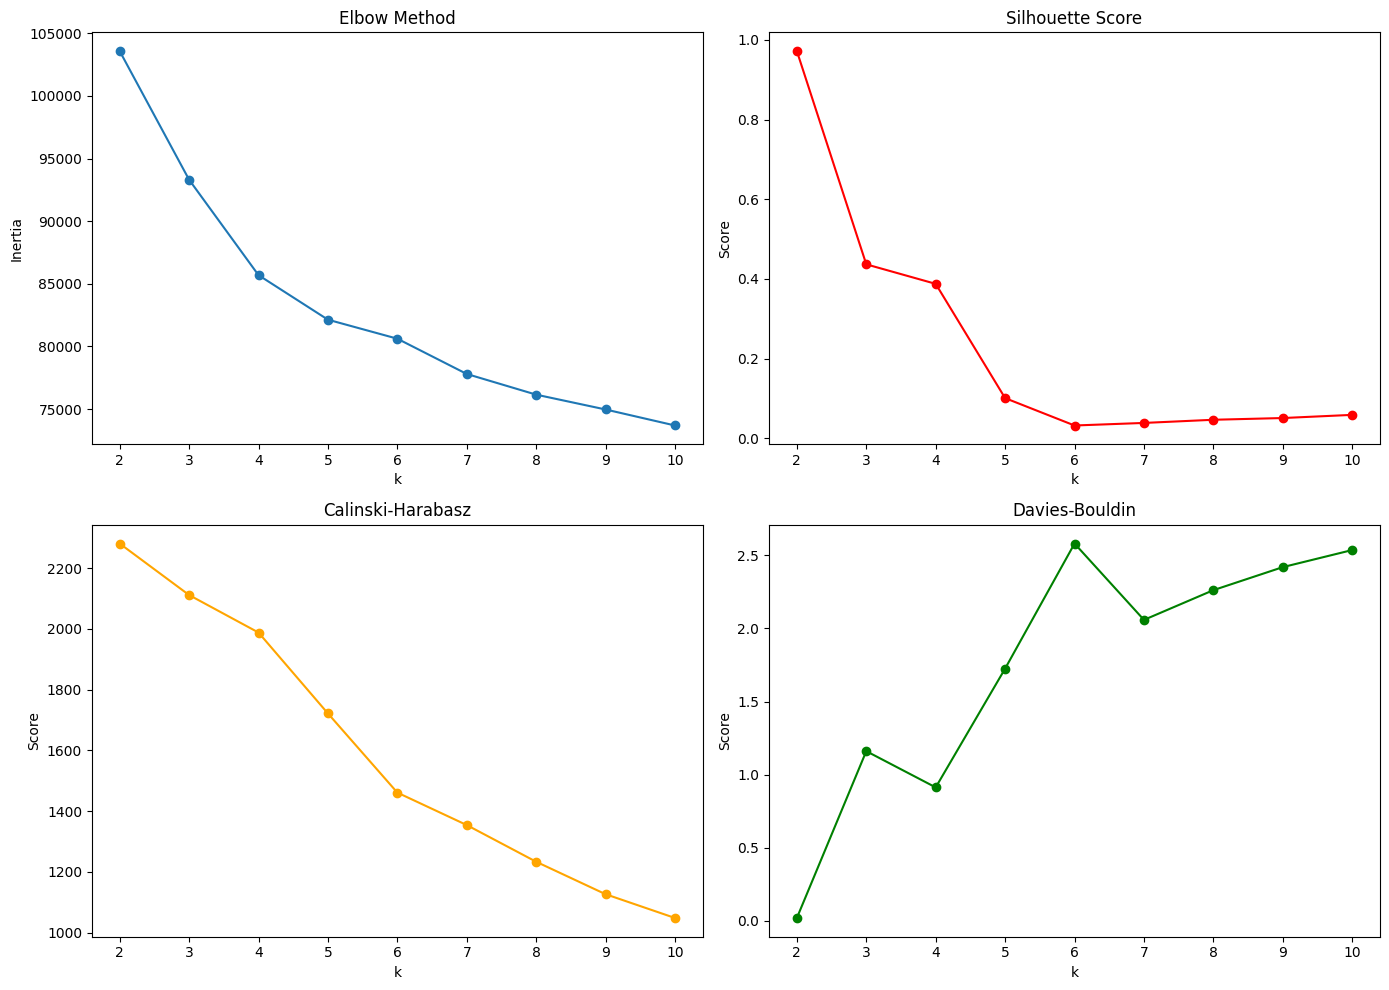

In [245]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))

# Elbow
axs[0,0].plot(k_values, inertia, marker='o')
axs[0,0].set_title('Elbow Method')
axs[0,0].set_xlabel('k')
axs[0,0].set_ylabel('Inertia')

# Silhouette
axs[0,1].plot(k_values, sil_scores, marker='o', color='red')
axs[0,1].set_title('Silhouette Score')
axs[0,1].set_xlabel('k')
axs[0,1].set_ylabel('Score')

# Calinski-Harabasz
axs[1,0].plot(k_values, calinski_scores, marker='o', color='orange')
axs[1,0].set_title('Calinski-Harabasz')
axs[1,0].set_xlabel('k')
axs[1,0].set_ylabel('Score')

# Davies-Bouldin
axs[1,1].plot(k_values, davies_scores, marker='o', color='green')
axs[1,1].set_title('Davies-Bouldin')
axs[1,1].set_xlabel('k')
axs[1,1].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [246]:
kmeans_4 = KMeans(n_clusters=4, random_state=12345, n_init=10)
df_cluster['cluster_4'] = kmeans_4.fit_predict(X_cluster)

kmeans_5 = KMeans(n_clusters=5, random_state=12345, n_init=10)
df_cluster['cluster_5'] = kmeans_5.fit_predict(X_cluster)

In [247]:
## K = 4

for c in sorted(df_cluster['cluster_4'].unique()):
    print(f"\n{'-'*50}")
    print(f"CLUSTER {c}")
    print('-'*50)

    temp = df_cluster[df_cluster['cluster_4'] == c]

    for col in ['mainaccord1','mainaccord2','mainaccord3']:
        print(f"\nTop {col}:")
        print(temp[col].value_counts().head(10))


--------------------------------------------------
CLUSTER 0
--------------------------------------------------

Top mainaccord1:
mainaccord1
citrus          1983
woody           1797
fruity          1444
white floral    1170
floral          1049
aromatic         920
amber            801
sweet            797
warm spicy       793
vanilla          647
Name: count, dtype: int64

Top mainaccord2:
mainaccord2
woody           1589
citrus          1170
aromatic        1144
sweet           1117
fruity           985
floral           849
warm spicy       761
white floral     728
powdery          693
fresh spicy      666
Name: count, dtype: int64

Top mainaccord3:
mainaccord3
woody          1453
sweet          1074
citrus          968
aromatic        888
powdery         844
fresh spicy     830
fruity          783
floral          729
warm spicy      715
vanilla         638
Name: count, dtype: int64

--------------------------------------------------
CLUSTER 1
-------------------------------------

In [248]:
df_cluster.groupby('cluster_4')[
    ['Rating Value','Rating Count','Year']
].mean().round(2)

,Rating Value,Rating Count,Year
cluster_4,,,
0,4.0,529.85,2013.68
1,4.0,9452.83,2006.80
2,4.0,853.16,1957.16
3,3.0,116.00,2014.00


In [249]:
## K = 5

for c in sorted(df_cluster['cluster_5'].unique()):
    print(f"\n{'-'*60}")
    print(f"CLUSTER {c}")
    print('-'*60)

    temp = df_cluster[df_cluster['cluster_5'] == c]

    for col in ['mainaccord1', 'mainaccord2', 'mainaccord3']:
        print(f"\nTop {col}:")
        print(temp[col].value_counts().head(10))


------------------------------------------------------------
CLUSTER 0
------------------------------------------------------------

Top mainaccord1:
mainaccord1
citrus          1677
woody           1538
fruity          1253
white floral     963
floral           824
sweet            740
amber            714
aromatic         705
warm spicy       655
vanilla          594
Name: count, dtype: int64

Top mainaccord2:
mainaccord2
woody           1267
sweet            978
citrus           972
aromatic         927
fruity           888
floral           704
warm spicy       665
white floral     623
vanilla          595
powdery          562
Name: count, dtype: int64

Top mainaccord3:
mainaccord3
woody          1221
sweet           953
citrus          829
aromatic        736
fruity          698
powdery         690
fresh spicy     639
warm spicy      602
floral          597
vanilla         572
Name: count, dtype: int64

------------------------------------------------------------
CLUSTER 1
-------

In [250]:
df_cluster.groupby('cluster_4')[
    ['Rating Value', 'Rating Count', 'Year']
].mean().round(2)

,Rating Value,Rating Count,Year
cluster_4,,,
0,4.0,529.85,2013.68
1,4.0,9452.83,2006.80
2,4.0,853.16,1957.16
3,3.0,116.00,2014.00


In [251]:
### Vamos a juntar df

map_familia = df_filtrado.set_index('Perfume')['familia_olfativa'].to_dict()

df_perfumes['familia_olfativa'] = df_perfumes['nombre'].map(map_familia)

In [252]:
map_familia

{'accento-overdose-pride-edition': 'Floral',
 'classique-pride-2023': 'Sweet / Gourmand',
 'le-male-pride-collector': 'Woody / Amber',
 'le-male-pride-2023': 'Sweet / Gourmand',
 'le-male-pride-2024': 'Floral',
 'polo-red-pride-edition': 'Woody / Amber',
 'le-male-pride-edition': 'Floral',
 'donald-trump': 'Green / Earthy',
 'glamour-gold-glam': 'Floral',
 'clean-simply-soap': 'Floral',
 'malbec-sport': 'Woody / Amber',
 'classique-pride-edition': 'Floral',
 'wild-carrot-oud': 'Floral',
 'dodo-edition-2020': 'Fresh / Citrus',
 'cafe': 'Woody / Amber',
 '1-million': 'Woody / Amber',
 'new-look-2024': 'Woody / Amber',
 'lesnaa-malina-i-dusica-wild-raspberries-and-oregano': 'Sweet / Gourmand',
 'love-pulse': 'Floral',
 'egeo-on-you': 'Woody / Amber',
 'uviolet': 'Floral',
 'scarlet-rain': 'Floral',
 'western-leather-white': 'Sweet / Gourmand',
 'success': 'Sweet / Gourmand',
 'chic-blossom': 'Floral',
 'lagerfeld-femme': 'Green / Earthy',
 'pearl': 'Floral',
 'tutti-twilly-d-hermes': 'Woo

In [253]:
def asignar_familia_perfumes_score(row):
    accords = str(row['accords']).lower()

    familias = {
        'Sweet / Gourmand': ['vanilla', 'sweet', 'gourmand', 'caramel', 'chocolate', 'lactonic', 'coffee', 'cacao'],
        'Floral': ['floral', 'white floral', 'rose', 'tuberose', 'powdery', 'yellow floral', 'violet'],
        'Woody / Amber': ['woody', 'amber', 'warm spicy', 'leather', 'tobacco', 'smoky', 'oud', 'balsamic'],
        'Green / Earthy': ['green', 'earthy', 'herbal', 'mossy'],
        'Fresh / Citrus': ['citrus', 'aromatic', 'aquatic', 'fresh', 'ozonic', 'marine']
    }

    scores = {}

    for familia, keywords in familias.items():
        score = sum(1 for kw in keywords if kw in accords)
        scores[familia] = score

    max_score = max(scores.values())

    if max_score == 0:
        return 'Other'

    # Si hay empate, priorizamos la familia más distintiva
    prioridad = [
        'Sweet / Gourmand',
        'Floral',
        'Woody / Amber',
        'Fresh / Citrus',
        'Green / Earthy'
    ]

    candidatas = [fam for fam, score in scores.items() if score == max_score]

    for fam in prioridad:
        if fam in candidatas:
            return fam

In [254]:
df_perfumes['familia_olfativa'] = df_perfumes.apply(
    asignar_familia_perfumes_score,
    axis=1
)

In [255]:
df_perfumes['familia_olfativa'].value_counts()

,count
familia_olfativa,
Woody / Amber,324
Floral,305
Fresh / Citrus,221
Sweet / Gourmand,192
Green / Earthy,3


In [256]:
for fam in df_perfumes['familia_olfativa'].unique():
    print(f"\n{'='*60}")
    print(f"FAMILIA: {fam}")
    print('='*60)

    display(
        df_perfumes[df_perfumes['familia_olfativa'] == fam][
            ['nombre', 'marca', 'accords']
        ].sample(
            min(10, len(df_perfumes[df_perfumes['familia_olfativa'] == fam])),
            random_state=42
        )
    )


FAMILIA: Woody / Amber


,nombre,marca,accords
333,Herod Parfums de Marly for men,Parfums de Marly,tobacco | vanilla | warm spicy | cinnamon | am...
267,Interlude 53 Man Amouage for men,Amouage,amber | smoky | woody | balsamic | warm spicy ...
349,Pegasus Exclusif Parfums de Marly for men,Parfums de Marly,woody | almond | vanilla | powdery | warm spic...
27,Sauvage Elixir Dior for men,Dior,warm spicy | fresh spicy | woody | aromatic | ...
504,Supremacy Not Only Intense Afnan for men,Afnan,fruity | mossy | woody | earthy | citrus | fre...
310,Sand Desert At Sunset Zara for men,Zara,warm spicy | cinnamon | amber | sweet | vanill...
642,Bad Boy Elixir Carolina Herrera for men,Carolina Herrera,leather | woody | animalic | aromatic | smoky ...
550,By the Fireplace Maison Martin Margiela for wo...,Maison Martin Margiela,woody | vanilla | balsamic | warm spicy | ambe...
817,Eau des Merveilles Hermès for women,Hermès,woody | aromatic | fresh spicy | citrus | ambe...
384,Devotion Pour Homme Dolce&Gabbana for men,Dolce&Gabbana,coffee | warm spicy | citrus | patchouli | woody



FAMILIA: Sweet / Gourmand


,nombre,marca,accords
284,Cruz del Sur II Xerjoff for women and men,Xerjoff,fruity | tropical | sweet | lactonic | woody
748,Sweetest Song Bath & Body Works for women,Bath & Body Works,sweet | fruity | musky | powdery | vanilla
459,Coconut Lagoon PARIS CORNER for women and men,PARIS CORNER,citrus | coconut | vanilla | sweet | ozonic | ...
838,Infusion d'Amande Prada for women and men,Prada,almond | vanilla | powdery | sweet | musky | n...
648,212 VIP Black Elixir Carolina Herrera for men,Carolina Herrera,vanilla | soft spicy | lavender | sweet | bals...
994,Burberry Her Parfum Burberry for women,Burberry,sweet | cherry | vanilla | amber | earthy | pa...
71,Black Opium Le Parfum Yves Saint Laurent for w...,Yves Saint Laurent,vanilla | warm spicy | coffee | sweet | white ...
100,Emporio Armani Stronger With You Intensely Gio...,Giorgio Armani,vanilla | sweet | amber | cinnamon | warm spic...
79,Shalimar L'Essence Guerlain for women,Guerlain,vanilla | powdery | amber | iris | sweet | mus...
24,Noble Blush Lattafa Perfumes for women,Lattafa Perfumes,sweet | powdery | almond | vanilla | musky | w...



FAMILIA: Fresh / Citrus


,nombre,marca,accords
559,Sailing Day Maison Martin Margiela for women a...,Maison Martin Margiela,marine | aromatic | aldehydic | aquatic | wood...
660,Lilyphéa Diptyque for women and men,Diptyque,ozonic | aquatic | warm spicy | vanilla | fres...
422,Bamboo Harmony By Kilian for women and men,By Kilian,citrus | green | fresh | woody | fresh spicy |...
820,Eau d'Orange Verte Hermès for women and men,Hermès,citrus | aromatic | green | earthy | mossy | w...
86,Aqua Allegoria Mandarine Basilic Guerlain for ...,Guerlain,citrus | fresh spicy | green | aromatic | fres...
506,Rare Reef Afnan for women and men,Afnan,citrus | fruity | aromatic | fresh spicy | gre...
803,Terre d’Hermès Intense Hermès for men,Hermès,coffee | fresh spicy | warm spicy | woody | so...
982,Hero Burberry for men,Burberry,woody | fresh spicy | aromatic | citrus | powdery
356,Versace Man Eau Fraiche Versace for men,Versace,citrus | aromatic | woody | fruity | fresh spi...
603,Valentino Uomo Born in Roma Valentino for men,Valentino,mineral | woody | ozonic | aromatic | aquatic ...



FAMILIA: Floral


,nombre,marca,accords
682,L'Interdit Eau de Parfum Rouge Ultime Givenchy...,Givenchy,white floral | tuberose | cacao | warm spicy |...
621,Valentino Donna Valentino for women,Valentino,iris | rose | powdery | leather | vanilla | ea...
467,Eshal Vanilla PARIS CORNER for women,PARIS CORNER,sweet | vanilla | powdery | musky | caramel | ...
870,Tears From The Moon Gucci for women and men,Gucci,white floral | fresh | floral | rose | green |...
268,Honour Woman Amouage for women,Amouage,white floral | tuberose | green | aromatic | a...
38,Dior Homme Cologne 2022 Dior for men,Dior,citrus | musky | fresh spicy | white floral | ...
488,Lady Million Rabanne for women,Rabanne,white floral | sweet | honey | citrus | fruity...
626,Good Girl Blush Carolina Herrera for women,Carolina Herrera,floral | vanilla | fresh | citrus | sweet | ye...
657,Do Son Eau de Parfum Diptyque for women and men,Diptyque,tuberose | white floral | musky | animalic | g...
168,Gaultier Divine Le Parfum Jean Paul Gaultier f...,Jean Paul Gaultier,amber | floral | white floral | tropical | sal...



FAMILIA: Green / Earthy


,nombre,marca,accords
145,Beau De Jour Eau de Parfum Tom Ford for men,Tom Ford,aromatic | fresh spicy | lavender | woody | ea...
261,Beach Hut Man Amouage for men,Amouage,green | woody | aromatic | earthy | mossy | fr...
811,H24 Eau de Parfum Hermès for men,Hermès,mossy | aromatic | woody | earthy | soft spicy...


In [257]:
df_perfumes['texto_modelo_olfativo'] = (
    df_perfumes['accords'].fillna('') + ' ' +
    df_perfumes['accords'].fillna('') + ' ' +   # le damos más peso a accords
    df_perfumes['top_notes'].fillna('') + ' ' +
    df_perfumes['middle_notes'].fillna('') + ' ' +
    df_perfumes['base_notes'].fillna('')
)

In [258]:
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'\s+', ' ', texto)
    texto = re.sub(r'[^a-z0-9áéíóúñü ,|.-]', ' ', texto)
    return texto.strip()

df_perfumes['texto_modelo_olfativo'] = df_perfumes['texto_modelo_olfativo'].apply(limpiar_texto)

In [259]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_olf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

tfidf_olf = vectorizer_olf.fit_transform(df_perfumes['texto_modelo_olfativo'])

In [260]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix_olf = cosine_similarity(tfidf_olf, tfidf_olf)

In [261]:
def recomendar_perfumes(
    nombre_perfume,
    df,
    sim_matrix,
    top_n=5,
    min_rating=4.0,
    min_votes=100,
    peso_sim=0.70,
    peso_rating=0.15,
    peso_votes=0.15
):
    nombre_perfume = nombre_perfume.lower().strip()

    exactos = df[df['nombre'].str.lower().str.strip() == nombre_perfume]

    if len(exactos) == 1:
        idx = exactos.index[0]
    elif len(exactos) > 1:
        return exactos[['nombre', 'marca', 'familia_olfativa', 'rating', 'votes']].reset_index(drop=True)
    else:
        match = df[df['nombre'].str.lower().str.contains(nombre_perfume, na=False)]

        if match.empty:
            return "No encontrado"

        if len(match) > 1:
            return match[['nombre', 'marca', 'familia_olfativa', 'rating', 'votes']].head(10).reset_index(drop=True)

        idx = match.index[0]

    perfume_base = df.loc[idx, 'nombre']
    familia_base = df.loc[idx, 'familia_olfativa']

    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    candidatos = []

    votos_log = np.log1p(df['votes'].fillna(0))
    votos_max = votos_log.max() if votos_log.max() > 0 else 1

    for i, sim in sim_scores[1:]:
        if i == idx:
            continue

        fila = df.loc[i]

        misma_familia = fila['familia_olfativa'] == familia_base
        rating_ok = pd.notnull(fila['rating']) and fila['rating'] >= min_rating
        votes_ok = pd.notnull(fila['votes']) and fila['votes'] >= min_votes

        if misma_familia and rating_ok and votes_ok:
            rating_norm = fila['rating'] / 10 if pd.notnull(fila['rating']) else 0
            votes_norm = np.log1p(fila['votes']) / votos_max if pd.notnull(fila['votes']) else 0

            score_final = (
                peso_sim * sim +
                peso_rating * rating_norm +
                peso_votes * votes_norm
            )

            candidatos.append((i, sim, score_final))

        if len(candidatos) >= top_n:
            break

    if len(candidatos) < top_n:
        usados = {c[0] for c in candidatos}
        usados.add(idx)

        for i, sim in sim_scores[1:]:
            if i in usados:
                continue

            fila = df.loc[i]
            rating_ok = pd.notnull(fila['rating']) and fila['rating'] >= min_rating
            votes_ok = pd.notnull(fila['votes']) and fila['votes'] >= min_votes

            if rating_ok and votes_ok:
                rating_norm = fila['rating'] / 10 if pd.notnull(fila['rating']) else 0
                votes_norm = np.log1p(fila['votes']) / votos_max if pd.notnull(fila['votes']) else 0

                score_final = (
                    peso_sim * sim +
                    peso_rating * rating_norm +
                    peso_votes * votes_norm
                )

                candidatos.append((i, sim, score_final))

            if len(candidatos) >= top_n:
                break

    candidatos = sorted(candidatos, key=lambda x: x[2], reverse=True)[:top_n]

    idxs = [c[0] for c in candidatos]

    resultados = df.loc[idxs, [
        'nombre', 'marca', 'familia_olfativa', 'rating', 'votes', 'accords'
    ]].copy()

    resultados['similaridad'] = [round(c[1], 3) for c in candidatos]
    resultados['score_final'] = [round(c[2], 3) for c in candidatos]
    resultados['perfume_base'] = perfume_base
    resultados['familia_base'] = familia_base

    return resultados.reset_index(drop=True)

In [262]:
def buscar_perfume(nombre_perfume, df, top_n=10):
    nombre_perfume = nombre_perfume.lower().strip()

    match = df[df['nombre'].str.lower().str.contains(nombre_perfume, na=False)]

    if match.empty:
        return "No encontrado"

    return match[['nombre', 'marca', 'familia_olfativa', 'rating', 'votes']].head(top_n).reset_index()

In [263]:
recomendar_perfumes("Ultra Male", df_perfumes, sim_matrix_olf)

,nombre,marca,familia_olfativa,rating,votes,accords,similaridad,score_final,perfume_base,familia_base
0,Liz Aura O Boticário for women,O Boticário,Sweet / Gourmand,4.25,320.0,vanilla | powdery | amber | fruity | fresh | i...,0.324,0.373,Ultra Male Jean Paul Gaultier for men,Sweet / Gourmand
1,Odyssey Mandarin Sky Elixir Armaf for women an...,Armaf,Sweet / Gourmand,7.79,451.0,citrus | vanilla | sweet | caramel | aromatic ...,0.166,0.321,Ultra Male Jean Paul Gaultier for men,Sweet / Gourmand
2,212 VIP Black Carolina Herrera for men,Carolina Herrera,Sweet / Gourmand,4.29,3654.0,aromatic | vanilla | soft spicy | anis | laven...,0.176,0.305,Ultra Male Jean Paul Gaultier for men,Sweet / Gourmand
3,Valentino Uomo Born in Roma Purple Melancholia...,Valentino,Sweet / Gourmand,4.12,1121.0,coconut | warm spicy | lavender | aromatic | s...,0.198,0.301,Ultra Male Jean Paul Gaultier for men,Sweet / Gourmand
4,Ginger Biscuit Cologne (2023) Jo Malone London...,Jo Malone London,Sweet / Gourmand,4.28,1280.0,fresh spicy | vanilla | caramel | cinnamon | s...,0.173,0.288,Ultra Male Jean Paul Gaultier for men,Sweet / Gourmand


In [264]:
recomendar_perfumes("Khamrah", df_perfumes, sim_matrix_olf)

,nombre,marca,familia_olfativa,rating,votes
0,Khamrah Lattafa Perfumes for women and men,Lattafa Perfumes,Woody / Amber,2.97,26819.0
1,Khamrah Qahwa Lattafa Perfumes for women and men,Lattafa Perfumes,Sweet / Gourmand,7.79,13318.0
2,Khamrah Dukhan Lattafa Perfumes for men,Lattafa Perfumes,Woody / Amber,7.29,1867.0


In [265]:
recomendar_perfumes("Ombre Nomade", df_perfumes, sim_matrix_olf)

,nombre,marca,familia_olfativa,rating,votes,accords,similaridad,score_final,perfume_base,familia_base
0,Oud Maison Francis Kurkdjian for women and men,Maison Francis Kurkdjian,Woody / Amber,8.97,2224.0,warm spicy | oud | aromatic | woody | balsamic...,0.278,0.440,Ombre Nomade Louis Vuitton for women and men,Woody / Amber
1,Interlude 53 Man Amouage for men,Amouage,Woody / Amber,4.64,1438.0,amber | smoky | woody | balsamic | warm spicy ...,0.307,0.389,Ombre Nomade Louis Vuitton for women and men,Woody / Amber
2,Club de Nuit Intense Man Parfum Armaf for men,Armaf,Woody / Amber,5.99,3228.0,citrus | fruity | leather | woody | smoky | sw...,0.254,0.384,Ombre Nomade Louis Vuitton for women and men,Woody / Amber
3,Qaed Al Fursan Lattafa Perfumes for women and men,Lattafa Perfumes,Woody / Amber,5.19,6613.0,fruity | sweet | woody | tropical | fresh | am...,0.241,0.373,Ombre Nomade Louis Vuitton for women and men,Woody / Amber
4,King Armaf for men,Armaf,Woody / Amber,4.57,341.0,fruity | sweet | powdery | amber | warm spicy ...,0.243,0.322,Ombre Nomade Louis Vuitton for women and men,Woody / Amber


In [266]:
recomendar_perfumes("Acqua di Giò", df_perfumes, sim_matrix_olf)

,nombre,marca,familia_olfativa,rating,votes
0,Acqua di Giò Parfum Giorgio Armani for men,Giorgio Armani,Fresh / Citrus,5.19,6203.0
1,Acqua di Giò Profondo Giorgio Armani for men,Giorgio Armani,Fresh / Citrus,3.97,11360.0
2,Acqua di Giò Profumo Giorgio Armani for men,Giorgio Armani,Woody / Amber,9.90,16083.0
3,Acqua di Giò Elixir Giorgio Armani for men,Giorgio Armani,Fresh / Citrus,4.97,1355.0
4,Acqua di Giò Profondo Parfum Giorgio Armani fo...,Giorgio Armani,Fresh / Citrus,5.84,2003.0
5,Acqua di Giò Profondo Eau de Parfum (2024) Gio...,Giorgio Armani,Fresh / Citrus,9.84,1251.0
6,Acqua di Giò Eau de Parfum Giorgio Armani for men,Giorgio Armani,Fresh / Citrus,4.94,3638.0


In [267]:
buscar_perfume("Eros", df_perfumes)

,index,nombre,marca,familia_olfativa,rating,votes
0,266,Love Tuberose Amouage for women,Amouage,Floral,5.04,3178.0
1,351,Eros Versace for men,Versace,Fresh / Citrus,2.97,28822.0
2,352,Eros Flame Versace for men,Versace,Fresh / Citrus,2.59,17445.0
3,354,Eros Energy Versace for men,Versace,Fresh / Citrus,3.97,5290.0
4,357,Eros Eau de Parfum Versace for men,Versace,Sweet / Gourmand,1.94,8052.0
5,361,Eros Najim Versace for men,Versace,Woody / Amber,0.09,1595.0
6,364,Eros Parfum Versace for men,Versace,Fresh / Citrus,2.20,2743.0
7,373,Eros Pour Femme Versace for women,Versace,Floral,1.50,5021.0


In [268]:
df_perfumes['rating'].describe()

,rating
count,1045.000000
mean,4.561167
std,2.277332
min,0.000000
25%,2.990000
50%,4.190000
75%,5.840000
max,9.990000


<Axes: >

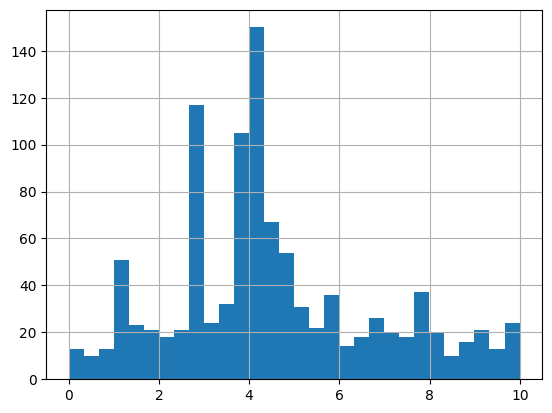

In [269]:
df_perfumes['rating'].hist(bins=30)

In [270]:
recomendar_perfumes(
    "Ultra Male",
    df_perfumes,
    sim_matrix,
    min_rating=5.0,
    min_votes=200,
    peso_sim=0.80,
    peso_rating=0.05,
    peso_votes=0.15
)

,nombre,marca,familia_olfativa,rating,votes,accords,similaridad,score_final,perfume_base,familia_base
0,La Belle Le Parfum Jean Paul Gaultier for women,Jean Paul Gaultier,Sweet / Gourmand,6.89,5169.0,vanilla | sweet | fruity | amber | white floral,0.246,0.354,Ultra Male Jean Paul Gaultier for men,Sweet / Gourmand
1,Scandal Jean Paul Gaultier for women,Jean Paul Gaultier,Sweet / Gourmand,7.54,9470.0,honey | sweet | white floral | citrus | carame...,0.216,0.341,Ultra Male Jean Paul Gaultier for men,Sweet / Gourmand
2,Scandal Le Parfum Jean Paul Gaultier for women,Jean Paul Gaultier,Sweet / Gourmand,5.24,2820.0,caramel | vanilla | white floral | sweet | sal...,0.242,0.333,Ultra Male Jean Paul Gaultier for men,Sweet / Gourmand
3,Odyssey Mandarin Sky Elixir Armaf for women an...,Armaf,Sweet / Gourmand,7.79,451.0,citrus | vanilla | sweet | caramel | aromatic ...,0.106,0.211,Ultra Male Jean Paul Gaultier for men,Sweet / Gourmand
4,Pear Potion PARIS CORNER for women and men,PARIS CORNER,Sweet / Gourmand,5.34,554.0,fruity | sweet | fresh | aquatic | green | car...,0.105,0.201,Ultra Male Jean Paul Gaultier for men,Sweet / Gourmand


In [271]:
def tokens_nombre(nombre):
    stop = {'for', 'women', 'men', 'and', 'eau', 'de', 'parfum', 'perfume'}
    tokens = re.findall(r'[a-z0-9]+', str(nombre).lower())
    return {t for t in tokens if t not in stop}

In [272]:
def recomendar_perfumes(
    nombre_perfume,
    df,
    sim_matrix,
    top_n=5,
    min_rating=5.0,
    min_votes=200,
    peso_sim=0.80,
    peso_rating=0.05,
    peso_votes=0.15,
    penalizar_misma_linea=True,
    excluir_misma_marca=False
):
    nombre_perfume = nombre_perfume.lower().strip()

    exactos = df[df['nombre'].str.lower().str.strip() == nombre_perfume]

    if len(exactos) == 1:
        idx = exactos.index[0]
    elif len(exactos) > 1:
        return exactos[['nombre', 'marca', 'familia_olfativa', 'rating', 'votes']].reset_index(drop=True)
    else:
        match = df[df['nombre'].str.lower().str.contains(nombre_perfume, na=False)]
        if match.empty:
            return "No encontrado"
        if len(match) > 1:
            return match[['nombre', 'marca', 'familia_olfativa', 'rating', 'votes']].head(10).reset_index(drop=True)
        idx = match.index[0]

    perfume_base = df.loc[idx, 'nombre']
    marca_base = df.loc[idx, 'marca']
    familia_base = df.loc[idx, 'familia_olfativa']
    tokens_base = tokens_nombre(perfume_base)

    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    votos_log = np.log1p(df['votes'].fillna(0))
    votos_max = votos_log.max() if votos_log.max() > 0 else 1

    candidatos = []

    for i, sim in sim_scores[1:]:
        if i == idx:
            continue

        fila = df.loc[i]

        misma_familia = fila['familia_olfativa'] == familia_base
        rating_ok = pd.notnull(fila['rating']) and fila['rating'] >= min_rating
        votes_ok = pd.notnull(fila['votes']) and fila['votes'] >= min_votes

        if not (misma_familia and rating_ok and votes_ok):
            continue

        if excluir_misma_marca and fila['marca'] == marca_base:
            continue

        sim_ajustada = sim

        if penalizar_misma_linea:
            tokens_candidato = tokens_nombre(fila['nombre'])
            overlap = len(tokens_base & tokens_candidato)
            if overlap >= 2:
                sim_ajustada -= 0.08
            elif overlap == 1:
                sim_ajustada -= 0.03

        rating_norm = fila['rating'] / 10 if pd.notnull(fila['rating']) else 0
        votes_norm = np.log1p(fila['votes']) / votos_max if pd.notnull(fila['votes']) else 0

        score_final = (
            peso_sim * sim_ajustada +
            peso_rating * rating_norm +
            peso_votes * votes_norm
        )

        candidatos.append((i, sim, sim_ajustada, score_final))

    candidatos = sorted(candidatos, key=lambda x: x[3], reverse=True)[:top_n]

    idxs = [c[0] for c in candidatos]

    resultados = df.loc[idxs, [
        'nombre', 'marca', 'familia_olfativa', 'rating', 'votes', 'accords'
    ]].copy()

    resultados['similaridad'] = [round(c[1], 3) for c in candidatos]
    resultados['sim_ajustada'] = [round(c[2], 3) for c in candidatos]
    resultados['score_final'] = [round(c[3], 3) for c in candidatos]
    resultados['perfume_base'] = perfume_base
    resultados['familia_base'] = familia_base

    return resultados.reset_index(drop=True)

In [273]:
recomendar_perfumes("Khamrah", df_perfumes, sim_matrix_olf, penalizar_misma_linea=False)

,nombre,marca,familia_olfativa,rating,votes
0,Khamrah Lattafa Perfumes for women and men,Lattafa Perfumes,Woody / Amber,2.97,26819.0
1,Khamrah Qahwa Lattafa Perfumes for women and men,Lattafa Perfumes,Sweet / Gourmand,7.79,13318.0
2,Khamrah Dukhan Lattafa Perfumes for men,Lattafa Perfumes,Woody / Amber,7.29,1867.0


In [274]:
recomendar_perfumes("Khamrah", df_perfumes, sim_matrix_olf, penalizar_misma_linea=True)

,nombre,marca,familia_olfativa,rating,votes
0,Khamrah Lattafa Perfumes for women and men,Lattafa Perfumes,Woody / Amber,2.97,26819.0
1,Khamrah Qahwa Lattafa Perfumes for women and men,Lattafa Perfumes,Sweet / Gourmand,7.79,13318.0
2,Khamrah Dukhan Lattafa Perfumes for men,Lattafa Perfumes,Woody / Amber,7.29,1867.0


In [275]:
recomendar_perfumes("Acqua di Giò", df_perfumes, sim_matrix_olf, penalizar_misma_linea=True, excluir_misma_marca=True)

,nombre,marca,familia_olfativa,rating,votes
0,Acqua di Giò Parfum Giorgio Armani for men,Giorgio Armani,Fresh / Citrus,5.19,6203.0
1,Acqua di Giò Profondo Giorgio Armani for men,Giorgio Armani,Fresh / Citrus,3.97,11360.0
2,Acqua di Giò Profumo Giorgio Armani for men,Giorgio Armani,Woody / Amber,9.90,16083.0
3,Acqua di Giò Elixir Giorgio Armani for men,Giorgio Armani,Fresh / Citrus,4.97,1355.0
4,Acqua di Giò Profondo Parfum Giorgio Armani fo...,Giorgio Armani,Fresh / Citrus,5.84,2003.0
5,Acqua di Giò Profondo Eau de Parfum (2024) Gio...,Giorgio Armani,Fresh / Citrus,9.84,1251.0
6,Acqua di Giò Eau de Parfum Giorgio Armani for men,Giorgio Armani,Fresh / Citrus,4.94,3638.0


In [276]:
df_perfumes.to_csv(path + 'df_perfumes_modelo_final.csv', index=False, encoding='utf-8-sig')

In [282]:
from google.colab import files
files.download(path + 'df_perfumes_modelo_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [277]:
## vamos a crear la función para recomendar por texto
from sklearn.metrics.pairwise import cosine_similarity

def recomendar_por_texto(
    texto_usuario,
    df,
    vectorizer,
    tfidf_matrix,
    top_n=5,
    min_rating=5.0,
    min_votes=200,
    peso_sim=0.80,
    peso_rating=0.05,
    peso_votes=0.15
):
    texto_usuario = limpiar_texto(texto_usuario)
    query_vec = vectorizer.transform([texto_usuario])
    sims = cosine_similarity(query_vec, tfidf_matrix).flatten()

    candidatos = []

    votos_log = np.log1p(df['votes'].fillna(0))
    votos_max = votos_log.max() if votos_log.max() > 0 else 1

    for i in np.argsort(sims)[::-1]:
        fila = df.iloc[i]

        rating_ok = pd.notnull(fila['rating']) and fila['rating'] >= min_rating
        votes_ok = pd.notnull(fila['votes']) and fila['votes'] >= min_votes

        if rating_ok and votes_ok:
            rating_norm = fila['rating'] / 10 if pd.notnull(fila['rating']) else 0
            votes_norm = np.log1p(fila['votes']) / votos_max if pd.notnull(fila['votes']) else 0

            score_final = (
                peso_sim * sims[i] +
                peso_rating * rating_norm +
                peso_votes * votes_norm
            )

            candidatos.append((i, sims[i], score_final))

        if len(candidatos) >= top_n:
            break

    candidatos = sorted(candidatos, key=lambda x: x[2], reverse=True)[:top_n]
    idxs = [c[0] for c in candidatos]

    resultados = df.iloc[idxs][[
        'nombre', 'marca', 'familia_olfativa', 'rating', 'votes', 'accords'
    ]].copy()

    resultados['similaridad'] = [round(c[1], 3) for c in candidatos]
    resultados['score_final'] = [round(c[2], 3) for c in candidatos]
    resultados['consulta_usuario'] = texto_usuario

    return resultados.reset_index(drop=True)

In [278]:
recomendar_por_texto(
    "vainilla dulce para noche",
    df_perfumes,
    vectorizer_olf,
    tfidf_olf
)

,nombre,marca,familia_olfativa,rating,votes,accords,similaridad,score_final,consulta_usuario
0,Good Girl Légère Carolina Herrera for women,Carolina Herrera,Woody / Amber,7.54,3748.0,sweet | white floral | lactonic | woody | citr...,0.165,0.288,vainilla dulce para noche
1,Cassili Parfums de Marly for women,Parfums de Marly,Floral,7.79,3273.0,floral | fruity | sweet | vanilla | fresh | tr...,0.000,0.155,vainilla dulce para noche
2,Meliora Parfums de Marly for women,Parfums de Marly,Fresh / Citrus,6.97,3539.0,fruity | soft spicy | fresh | aromatic | green...,0.000,0.152,vainilla dulce para noche
3,Safanad Parfums de Marly for women,Parfums de Marly,Floral,7.79,2505.0,sweet | white floral | citrus | vanilla | wood...,0.000,0.151,vainilla dulce para noche
4,Palatine Parfums de Marly for women,Parfums de Marly,Floral,9.09,1260.0,powdery | violet | floral | musky | woody | ci...,0.000,0.148,vainilla dulce para noche


In [279]:
recomendar_por_texto(
    "citrico fresco para calor",
    df_perfumes,
    vectorizer_olf,
    tfidf_olf
)

,nombre,marca,familia_olfativa,rating,votes,accords,similaridad,score_final,consulta_usuario
0,Maahir Legacy Lattafa Perfumes for men,Lattafa Perfumes,Fresh / Citrus,7.79,3554.0,aromatic | fresh spicy | citrus | green | wood...,0.0,0.156,citrico fresco para calor
1,Ameer Al Oudh Intense Oud Lattafa Perfumes for...,Lattafa Perfumes,Sweet / Gourmand,6.24,5673.0,woody | vanilla | sweet | oud | powdery | Next...,0.0,0.155,citrico fresco para calor
2,Victoria Lattafa Perfumes for women and men,Lattafa Perfumes,Floral,8.59,1844.0,vanilla | citrus | white floral | powdery | sweet,0.0,0.151,citrico fresco para calor
3,Khamrah Dukhan Lattafa Perfumes for men,Lattafa Perfumes,Woody / Amber,7.29,1867.0,amber | warm spicy | sweet | tobacco | balsami...,0.0,0.144,citrico fresco para calor
4,The Kingdom For Men Lattafa Perfumes for men,Lattafa Perfumes,Woody / Amber,5.34,2495.0,vanilla | aromatic | sweet | amber | lavender ...,0.0,0.139,citrico fresco para calor


In [280]:
recomendar_por_texto(
    "oud ahumado elegante",
    df_perfumes,
    vectorizer_olf,
    tfidf_olf
)

,nombre,marca,familia_olfativa,rating,votes,accords,similaridad,score_final,consulta_usuario
0,Ameer Al Oudh Intense Oud Lattafa Perfumes for...,Lattafa Perfumes,Sweet / Gourmand,6.24,5673.0,woody | vanilla | sweet | oud | powdery | Next...,0.371,0.452,oud ahumado elegante
1,Oud Satin Mood Maison Francis Kurkdjian for wo...,Maison Francis Kurkdjian,Floral,8.97,9572.0,rose | floral | oud | amber | vanilla,0.323,0.435,oud ahumado elegante
2,Bade'e Al Oud Oud for Glory Lattafa Perfumes f...,Lattafa Perfumes,Woody / Amber,7.79,7600.0,oud | warm spicy | fresh spicy | patchouli | m...,0.303,0.409,oud ahumado elegante
3,Oud Tobacco Montale for women and men,Montale,Woody / Amber,5.19,1544.0,sweet | citrus | tobacco | amber | fresh spicy...,0.340,0.403,oud ahumado elegante
4,Oud & Bergamot Jo Malone London for women and men,Jo Malone London,Fresh / Citrus,6.99,3057.0,citrus | oud | woody | fresh spicy | aromatic,0.298,0.388,oud ahumado elegante


In [281]:
recomendar_por_texto(
    "perfume floral elegante para mujer",
    df_perfumes,
    vectorizer_olf,
    tfidf_olf
)

,nombre,marca,familia_olfativa,rating,votes,accords,similaridad,score_final,consulta_usuario
0,Olene Eau de Toilette Diptyque for women,Diptyque,Floral,5.09,2209.0,white floral | floral | green | yellow floral ...,0.347,0.413,perfume floral elegante para mujer
1,Miss Dior Essence Dior for women,Dior,Floral,7.99,1289.0,fruity | woody | sweet | white floral | floral,0.252,0.344,perfume floral elegante para mujer
2,Good Girl Gone Bad By Kilian for women,By Kilian,Floral,6.97,8103.0,floral | white floral | fruity | tuberose | ye...,0.224,0.343,perfume floral elegante para mujer
3,Neroli Portofino Tom Ford for women and men,Tom Ford,Fresh / Citrus,6.97,8940.0,citrus | white floral | aromatic | fresh spicy...,0.201,0.326,perfume floral elegante para mujer
4,APOM Maison Francis Kurkdjian for women and men,Maison Francis Kurkdjian,Floral,5.99,885.0,white floral | sweet | musky | yellow floral |...,0.203,0.290,perfume floral elegante para mujer
